In [2]:
# 早期版本

import os
import re
import pandas as pd
from ase import Atoms
from ase.db import connect
from pathlib import Path
from tqdm import tqdm
from rdkit import Chem
import numpy as np
from DFTStructureGenerator.logfile_process import Logfile

OUTPUT_ASE_DB = "boron_ccl.db"
OUTPUT_PARQUET = "boron_ccl_dataset.parquet"

# 正则一次性解析所有类型（超级稳）
PATTERNS = {
    'borane':     re.compile(r'^B_(\d{5})$'),
    'ligand':     re.compile(r'^L_(\d{5})$'),
    'substrate':  re.compile(r'^Cl_(\d{5})_r$'),
    'complex_r':  re.compile(r'^B_(\d{5})_L_(\d{5})_r$'),
    'complex_p':  re.compile(r'^B_(\d{5})_L_(\d{5})_p$'),
    'ts':         re.compile(r'^B_(\d{5})_L_(\d{5})_Cl_(\d{5})$'),
    'c_radical':  re.compile(r'^Cl_(\d{5})_p$'),
}

def classify_key(key: str):
    """返回 (category, (bid, lid, clid))，未匹配的返回 ('unknown', None)"""
    for pat, regex in PATTERNS.items():
        m = regex.match(key)
        if m:
            groups = m.groups()
            groups = [int(each) for each in groups]
            if pat == 'borane':     return 'borane',    (groups[0], np.nan,  np.nan)
            if pat == 'ligand':     return 'ligand',    (np.nan,     groups[0], np.nan)
            if pat == 'substrate':  return 'substrate', (np.nan,     np.nan,     groups[0])
            if pat == 'complex_r':  return 'complex_r', (groups[0], groups[1], np.nan)
            if pat == 'complex_p':  return 'complex_p', (groups[0], groups[1], np.nan)
            if pat == 'ts':         return 'ts',        (groups[0], groups[1], groups[2])
            if pat == 'c_radical':  return 'c_radical', (np.nan,     np.nan,     groups[0])
    return 'unknown', None

def build_databases(data_dict: dict, rewrite: bool = True):
    if rewrite and os.path.exists(OUTPUT_ASE_DB):
        os.remove(OUTPUT_ASE_DB)

    db = connect(OUTPUT_ASE_DB)
    records = []

    for key, (smiles, atoms, gibbs_hartree) in data_dict.items():
        if atoms is None and smiles is None:
            continue

        category, ids = classify_key(key)
        bid, lid, clid = (ids if ids else (None, None, None))

        # 通用字段
        natoms = len(atoms) if atoms else None
        formula = atoms.get_chemical_formula() if atoms else None
        charge = int(atoms.get_initial_charges().sum()) if atoms else 0

        # ===================== 写入 ASE.db =====================
        data = {
            "smiles": smiles,
            "source_key": key,
            "category": category,
            "borane_id": bid,
            "ligand_id": lid,
            "substrate_id": clid,
            "gibbs_hartree": float(gibbs_hartree),
            "temperature_K": 298.15,
            "solvent": "toluene",
        }

        if category == 'ts':
            data["is_transition_state"] = True
            data["expected_imaginary_freqs"] = 1

        db.write(atoms, key=key, key_value_pairs=data)   # ASE 智能判断是 Atoms 还是 SMILES

        # ===================== 收集 Parquet 记录 =====================
        records.append({
            "key": key,
            "category": category,
            "borane_id": bid,
            "ligand_id": lid,
            "substrate_id": clid,
            "smiles": smiles if isinstance(smiles, str) else None,
            "natoms": natoms,
            "formula": formula,
            "charge": charge,
            "gibbs_hartree": float(gibbs_hartree),
            "atoms": atoms.numbers.tolist(), 
            "positions": atoms.positions.tolist()
        })

    # =========================== 自动计算能垒 ===========================
    df = pd.DataFrame(records)

    # 取出所有过渡态
    ts_df = df[df.category == "ts"].copy()
    ts_df["barrier_kcal"] = None
    ts_df["delta_g_rxn_kcal"] = None

    HARTREE_TO_KCAL = 627.509
    print('所有过渡态数量：', len(ts_df))
    for idx, row in ts_df.iterrows():
        bid, lid, clid = row[["borane_id", "ligand_id", "substrate_id"]]
        bid, lid, clid = int(bid), int(lid), int(clid)
        # Reactant = complex_r
        BLr_key = f"B_{bid:05}_L_{lid:05}_r"
        Clr_key = f'Cl_{clid:05}_r'
        if BLr_key in df.key.values and Clr_key in df.key.values:
            BLg_r = df[df.key == BLr_key].gibbs_hartree.iloc[0]
            Clg_r = df[df.key == Clr_key].gibbs_hartree.iloc[0]
            ts_g = row.gibbs_hartree
            ts_df.loc[idx, "barrier_kcal"] = (ts_g - BLg_r - Clg_r) * HARTREE_TO_KCAL
        else:
            print(bid, lid, clid, "Not Found")
        # Products = complex_p + c_radical
        p_key = f"B_{bid:05}_L_{lid:05}_p"
        c_key = f"Cl_{clid:05}_p"
        if p_key in df.key.values and c_key in df.key.values and BLr_key in df.key.values and Clr_key in df.key.values:
            g_p = df[df.key == p_key].gibbs_hartree.iloc[0] + df[df.key == c_key].gibbs_hartree.iloc[0]
            g_r_total = BLg_r + Clg_r
            ts_df.loc[idx, "delta_g_rxn_kcal"] = (g_p - g_r_total) * HARTREE_TO_KCAL

    # 合并回主表（所有非TS的行 barrier/deltaG 都是 NaN，正好）
    final_df = df.merge(ts_df[["key", "barrier_kcal", "delta_g_rxn_kcal"]], on="key", how="left")

    # 保存
    final_df.to_parquet(OUTPUT_PARQUET, index=False, compression="zstd")
    print(f"建库完成！")
    print(f"  ASE 数据库      : {OUTPUT_ASE_DB}    ({db.count()} 条记录)")
    print(f"  Parquet 数据集  : {OUTPUT_PARQUET} ({len(final_df)} 行)")
    print(f"  成功计算能垒的反应数: {final_df.barrier_kcal.notna().sum()}")

# ============================== 使用示例 ==============================

In [131]:
# =============================================================================
# 硼自由基催化C-Cl活化数据集 一键结构化建库脚本（2025 增强版）
# 新增：ASE.db 中存储 ΔG‡ / ΔG_rxn + 双向反应映射
# =============================================================================

import os
import re
import pandas as pd
import numpy as np
from ase import Atoms
from ase.db import connect

OUTPUT_ASE_DB = "boron_ccl.db"
OUTPUT_PARQUET = "boron_ccl_dataset.parquet"

# 正则模式（已适配您最新的 Cl_xxxxx_r）
PATTERNS = {
    'borane':     re.compile(r'^B_(\d{5})$'),
    'ligand':     re.compile(r'^L_(\d{5})$'),
    'substrate':  re.compile(r'^Cl_(\d{5})_r$'),        # reactant 底物
    'complex_r':  re.compile(r'^B_(\d{5})_L_(\d{5})_r$'),
    'complex_p':  re.compile(r'^B_(\d{5})_L_(\d{5})_p$'),
    'ts':         re.compile(r'^B_(\d{5})_L_(\d{5})_Cl_(\d{5})$'),
    'c_radical':  re.compile(r'^Cl_(\d{5})_p$'),
}

def classify_key(key: str):
    for pat, regex in PATTERNS.items():
        m = regex.match(key)
        if m:
            groups = [int(g) for g in m.groups()]
            if pat == 'borane':     return 'borane',    (groups[0], np.nan, np.nan)
            if pat == 'ligand':     return 'ligand',    (np.nan, groups[0], np.nan)
            if pat == 'substrate':  return 'substrate', (np.nan, np.nan, groups[0])
            if pat == 'complex_r':  return 'complex_r', (groups[0], groups[1], np.nan)
            if pat == 'complex_p':  return 'complex_p', (groups[0], groups[1], np.nan)
            if pat == 'ts':         return 'ts',        (groups[0], groups[1], groups[2])
            if pat == 'c_radical':  return 'c_radical', (np.nan, np.nan, groups[0])
    return 'unknown', None

def build_databases(data_dict: dict, rewrite: bool = True):
    if rewrite and os.path.exists(OUTPUT_ASE_DB):
        os.remove(OUTPUT_ASE_DB)

    db = connect(OUTPUT_ASE_DB)
    records = []
    ts_mapping = {}
    reactant_to_ts = {}

    HARTREE_TO_KCAL = 627.509

    # ===================== 第一遍：写入所有结构 =====================
    for key, (smiles, atoms, gibbs_hartree) in data_dict.items():
        if atoms is None and smiles is None:
            continue

        category, ids = classify_key(key)
        if category == 'unknown':
            print(f"Warning: 未识别的key: {key}")
            continue

        bid, lid, clid = ids
        natoms = len(atoms) if atoms else np.nan
        formula = atoms.get_chemical_formula() if atoms else None
        charge = int(atoms.get_initial_charges().sum()) if atoms else 0

        # ==================== 可搜索字段放入 kvp ====================
        kvp = {
            "category": category,
            "borane_id": float(bid),
            "ligand_id": float(lid),
            "substrate_id": float(clid),
            "gibbs_hartree": float(gibbs_hartree),
            "charge": charge,
            "temperature_K": 298.15,
            "solvent": "toluene",
            "smiles": smiles if isinstance(smiles, str) else None,
            "source_key": key,
            
        }

        # TS 专属标记（可搜索）
        if category == 'ts':
            kvp.update({
                "is_transition_state": True,
                "expected_imaginary_freqs": 1,
            })

        # ==================== 复杂/非标量字段放入 data ====================
        data_dict_for_ase = {
            "formula": formula,
        }

        # 写入：kvp 用于搜索，data 用于存储复杂信息
        db.write(atoms, key=key, key_value_pairs=kvp, data=data_dict_for_ase)

        # Parquet 记录（不变）
        records.append({
            "key": key,
            "category": category,
            "borane_id": bid,
            "ligand_id": lid,
            "substrate_id": clid,
            "smiles": smiles,
            "natoms": natoms,
            "formula": formula,
            "charge": charge,
            "gibbs_hartree": float(gibbs_hartree),
            "numbers": atoms.numbers.tolist() if atoms else None,
            "positions": atoms.positions.tolist() if atoms else None,
        })

        # 映射收集（不变）
        if category == 'ts':
            b5 = f"{int(bid):05}"
            l5 = f"{int(lid):05}"
            c5 = f"{int(clid):05}"
            ts_mapping[key] = {
                "reactant_complex": f"B_{b5}_L_{l5}_r",
                "reactant_substrate": f"Cl_{c5}_r",
                "product_complex": f"B_{b5}_L_{l5}_p",
                "product_c_radical": f"Cl_{c5}_p",
            }
            reactant_to_ts.setdefault(f"B_{b5}_L_{l5}_r", []).append(key)
            reactant_to_ts.setdefault(f"Cl_{c5}_r", []).append(key)

    # ===================== 第二遍：计算能垒并 UPDATE kvp =====================
    df = pd.DataFrame(records)
    updated_rows = []
    for ts_key, mapping in ts_mapping.items():
        r_complex_key = mapping["reactant_complex"]
        r_sub_key = mapping["reactant_substrate"]
        p_complex_key = mapping["product_complex"]
        p_rad_key = mapping["product_c_radical"]

        row_ts = db.get(key=ts_key)  # 用 key 获取更稳
        g_ts = row_ts.gibbs_hartree

        barrier = np.nan
        delta_g = np.nan

        if r_complex_key in df['key'].values and r_sub_key in df['key'].values:
            g_r_complex = df[df.key == r_complex_key].gibbs_hartree.iloc[0]
            g_r_sub = df[df.key == r_sub_key].gibbs_hartree.iloc[0]
            barrier = (g_ts - g_r_complex - g_r_sub) * HARTREE_TO_KCAL

        if all(k in df['key'].values for k in [p_complex_key, p_rad_key, r_complex_key, r_sub_key]):
            g_p_complex = df[df.key == p_complex_key].gibbs_hartree.iloc[0]
            g_p_rad = df[df.key == p_rad_key].gibbs_hartree.iloc[0]
            delta_g = (g_p_complex + g_p_rad - g_r_complex - g_r_sub) * HARTREE_TO_KCAL


        db.update(row_ts.id,
                  barrier_kcal=barrier,
                  delta_g_rxn_kcal=delta_g,
                  reactant_complex_key=r_complex_key,
                  reactant_substrate_key=r_sub_key,
                  product_complex_key=p_complex_key,
                  product_c_radical_key=p_rad_key)
        # 更新 Parquet 记录
        updated_rows.append({
            "key": ts_key,
            "barrier_kcal": barrier,
            "delta_g_rxn_kcal": delta_g,
            **mapping
        })

    # 更新 reactant 的 associated_ts_keys
    for reactant_key, ts_list in reactant_to_ts.items():
        row = db.get(key=reactant_key)
        db.update(row.id, data={"associated_ts_keys": ts_list})  # 列表放 data

    # ===================== 合并到 Parquet =====================
    update_df = pd.DataFrame(updated_rows)
    final_df = df.merge(update_df, on="key", how="left")

    final_df.to_parquet(OUTPUT_PARQUET, index=False, compression="zstd")

    print(f"建库完成！")
    print(f"  ASE 数据库      : {OUTPUT_ASE_DB}    ({db.count()} 条记录)")
    print(f"  Parquet 数据集  : {OUTPUT_PARQUET} ({len(final_df)} 行)")
    print(f"  成功计算能垒的过渡态数: {final_df.barrier_kcal.notna().sum()}")

# ============================== 使用示例 ==============================

In [4]:
duplicate_N_id = [9, 43, 285, 310, 314, 345, 346, 347, 348, 349, 350, 351, 352, 353, 354, 355, 356, 357, 358, 359, 360, 361, 362, 372, 375, 376]

In [ ]:
from tqdm import tqdm
from rdkit import Chem
from DFTStructureGenerator.logfile_process import Logfile
Borane_df = pd.read_csv(r'Data\All_Data\reactants_B.csv')
Ligand_df = pd.read_csv(r'Data\All_Data\reactants_N.csv').dropna(subset=['G_energy_r'])
Cl_df = pd.read_csv(r'Data\All_Data\reactants_Cl_old.csv')
Borane_Ligand_df = pd.read_csv(r'Data\All_Data\reactants_B_N_old.csv')
reaction_df = pd.read_csv(r'E:\work\B_Cl_Nu\Sum\Borane_all.csv')
# raise NameError
combined_data = {}
temp_combined_data = {}
for row_id, row in Borane_df.iterrows():
    idx, conf_idxs_r, G = row['Index'], int(row['conf_idxs_r']), row['G_energy_r']
    mol = Chem.MolFromMolFile(rf'E:\work\B_Cl_Nu\Data\Mols\B_{idx:05}_r.mol', removeHs=False)
    [atom.SetAtomMapNum(atom.GetIdx()) for atom in mol.GetAtoms()]
    smiles = Chem.MolToSmiles(mol)
    log_file = rf'E:\work\B_Cl_Nu\Data\GS_OPT\B_single\B_{idx:05}_r_{conf_idxs_r:04}.log'
    log = Logfile(log_file)
    atoms = Atoms(symbols=log.symbol_list, positions=log.running_positions[-1])
    combined_data[f'B_{idx:05}'] = [smiles, atoms, G]

for row_id, row in Ligand_df.iterrows():
    idx, conf_idxs_r, G = row['Index'], int(row['conf_idxs_r']), row['G_energy_r']
    mol = Chem.MolFromMolFile(rf'E:\work\B_Cl_Nu\Data\Mols\N_{idx:05}_r.mol', removeHs=False)
    [atom.SetAtomMapNum(atom.GetIdx()) for atom in mol.GetAtoms()]
    smiles = Chem.MolToSmiles(mol)
    log_file = rf'E:\work\B_Cl_Nu\Data\GS_OPT\N_single\N_{idx:05}_r_{conf_idxs_r:04}.log'
    log = Logfile(log_file)
    atoms = Atoms(symbols=log.symbol_list, positions=log.running_positions[-1])
    combined_data[f'L_{idx:05}'] = [smiles, atoms, G]

for row_id, row in Cl_df.iterrows():
    idx, conf_idxs_r, conf_idxs_p, G_r, G_p = row['Index'], int(row['conf_idxs_r']), int(row['conf_idxs_p']), row['G_energy_r'], row['G_energy_p']
    for conf_id, state, G in [[conf_idxs_r, 'r', G_r], [conf_idxs_p, 'p', G_p]]:
        mol = Chem.MolFromMolFile(rf'E:\work\B_Cl_Nu\Data\Mols\Cl_{idx:05}_{state}.mol', removeHs=False)
        [atom.SetAtomMapNum(atom.GetIdx()) for atom in mol.GetAtoms()]
        smiles = Chem.MolToSmiles(mol)
        log_file = rf'E:\work\B_Cl_Nu\Data\GS_OPT\Cl_{state}\Cl_{idx:05}_{state}_{conf_id:04}.log'
        log = Logfile(log_file)
        atoms = Atoms(symbols=log.symbol_list, positions=log.running_positions[-1])
        combined_data[f'Cl_{idx:05}_{state}'] = [smiles, atoms, G]

BN_smiles = {}

for row_id, row in tqdm(reaction_df.iterrows()):
    B_idx, N_idx, Cl_idx, conf_id, G, N_atom = row['B_Index'], row['N_Index'], row['Cl_Index'], row['conf_idxs_ts'], row['TS_G'], int(row['N_Atomid'])
    log_file = rf'E:\work\B_Cl_Nu\Sum\TS_needIRC\B_{B_idx:05}_Nu_{N_idx:05}_Cl_{Cl_idx:05}.log'
    if not os.path.exists(log_file):
        log_file = rf'E:\work\B_Cl_Nu\Sum\TS_needIRC\B_{B_idx:05}_Nu_{N_idx:05}_Cl_{Cl_idx:05}_{conf_id:04}.log'
    log = Logfile(log_file)
    atoms = Atoms(symbols=log.symbol_list, positions=log.running_positions[-1])
    temp_combined_data[f'B_{B_idx:05}_L_{N_idx:05}_Cl_{Cl_idx:05}'] = [None, atoms, G]
    BN_name = f'{B_idx:05}_{N_idx:05}'
    if N_idx in duplicate_N_id:
        BN_name = f'{B_idx:05}_{N_idx:05}_{N_atom}'

    BN_smiles[f'{BN_name}_r'] = row['AAM'].split(">>")[0].split('.')[0]
    BN_smiles[f'{BN_name}_p'] = row['AAM'].split(">>")[1].split('.')[0]


for row_id, row in tqdm(Borane_Ligand_df.iterrows()):
    B_idx, N_idx, conf_idxs_r, conf_idxs_p, G_r, G_p, N_atom = row['B_Index'], row['N_Index'], int(row['conf_idxs_r']), int(row['conf_idxs_p']), row['G_energy_r'], row['G_energy_p'], int(row['N_Atomid']) 
    for conf_id, state, G in [[conf_idxs_r, 'r', G_r], [conf_idxs_p, 'p', G_p]]:
        BN_name = f'{B_idx:05}_{N_idx:05}'
        if N_idx in duplicate_N_id:
            BN_name = f'{B_idx:05}_{N_idx:05}_{N_atom}'
        if f'{BN_name}_{state}' not in BN_smiles.keys():
            continue
        smiles = BN_smiles[f'{BN_name}_{state}']
        log_file = rf'E:\work\B_Cl_Nu\Data\GS_OPT\B_N_{state}\B_{B_idx:05}_Nu_{N_idx:05}_{state}_{conf_id:04}.log'
        if N_idx in duplicate_N_id:
            log_file = rf'E:\work\B_Cl_Nu\Data\GS_OPT\B_N_{state}_d\B_{B_idx:05}_Nu_{N_idx:05}_Naid_{N_atom:05}_{state}_{conf_id:04}.log'
        if not os.path.exists(log_file):
            print(BN_name, 'Not Found')
        log = Logfile(log_file)
        atoms = Atoms(symbols=log.symbol_list, positions=log.running_positions[-1])
        combined_data[f'B_{B_idx:05}_L_{N_idx:05}_{state}'] = [smiles, atoms, G]
combined_data = combined_data | temp_combined_data


9237it [02:38, 58.21it/s] 
20010it [02:41, 123.66it/s]


In [132]:
build_databases(combined_data, rewrite=True)

建库完成！
  ASE 数据库      : boron_ccl.db    (18763 条记录)
  Parquet 数据集  : boron_ccl_dataset.parquet (18763 行)
  成功计算能垒的过渡态数: 9237


In [126]:
from ase.db import connect
from rdkit import Chem

db = connect('boron_ccl.db')

# 例子1：找出所有硼上直接连了-CF3 的硼自由基
cf3 = Chem.MolFromSmarts("[#5]-C(F)(F)F")
for row in db.select(category="borane"):
    if row.smiles and Chem.MolFromSmiles(row.smiles).HasSubstructMatch(cf3):
        print("含CF3的硼:", row.key)


AttributeError: 'AtomsRow' object has no attribute 'smiles'

In [82]:
# 例子2：找出所有底物含苄基氯（Cl-CH2-Ph）的反应
benzyl_cl = Chem.MolFromSmarts("ClC[c]1ccccc1")
for row in db.select(category="ts"):
    if row.smiles and Chem.MolFromSmiles(row.smiles).HasSubstructMatch(benzyl_cl):
        print("苄基氯底物:", row.key)

In [87]:
len(df.delta_g_rxn_kcal.dropna())

8958

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_parquet("boron_ccl_dataset.parquet")

# 1. 能垒最低的 30 个反应（直接发论文表格）
print(df.nsmallest(30, "barrier_kcal")[["key", "borane_id", "ligand_id", "substrate_id", "barrier_kcal"]])

# 2. 每个配体平均能垒排行榜
print(df[df.category=="ts"].groupby("ligand_id")["barrier_kcal"].agg(["mean","count"]).sort_values("mean").head(20))

# 3. 火山图（ΔG_rxn vs ΔG‡）
ts = df[df.category=="ts"].dropna(subset=["barrier_kcal", "delta_g_rxn_kcal"])
sns.scatterplot(data=ts, x="delta_g_rxn_kcal", y="barrier_kcal", s=60, alpha=0.7)
plt.xlabel("ΔG_rxn (kcal/mol)"); plt.ylabel("ΔG‡ (kcal/mol)")
plt.axhline(20, color="red", linestyle="--"); plt.axvline(0, color="gray", linestyle="--")
plt.show()

# 4. 找出所有含氟硼的反应
from rdkit import Chem
f_borons = df[df.smiles.str.contains("F", na=False) & df.category.isin(["borane", "complex_r"])]
print(f"含氟硼自由基参与的低能垒反应数:", len(f_borons.merge(ts[ts.barrier_kcal<18])))

# # 5. DuckDB 极速查询（推荐装上，以后数据变大无敌）
# import duckdb
# duckdb.sql("""
#     SELECT substrate_id, COUNT(*) as n, AVG(barrier_kcal) as avg_barrier
#     FROM 'boron_ccl_dataset.parquet'
#     WHERE category='ts' AND barrier_kcal IS NOT NULL
#     GROUP BY substrate_id
#     HAVING n >= 5
#     ORDER BY avg_barrier
#     LIMIT 15
# """).show()

In [7]:
benchmark_b = [388, 391, 394, 401, 427] 
benchmark_l = [1, 33, 46, 69, 72, 146]
benchmark_cl = [443, 447, 475, 477, 490, 519, 506]
temp_reaction_df = reaction_df.loc[np.isin(reaction_df['B_Index'], benchmark_b) & np.isin(reaction_df['N_Index'], benchmark_l)& np.isin(reaction_df['Cl_Index'], benchmark_cl)]
calc_dict = {}
db = connect('boron_ccl.db')
for row_id, row in temp_reaction_df.iterrows():
    B_idx, N_idx, Cl_idx = row['B_Index'], row['N_Index'], row['Cl_Index']
    BN_name = f"B_{B_idx:05}_L_{N_idx:05}_r"
    Cl_name = f'Cl_{Cl_idx:05}_r'
    ts_name = f'B_{B_idx:05}_L_{N_idx:05}_Cl_{Cl_idx:05}'
    for name, multi in zip([BN_name, Cl_name, ts_name], [2,1,2]):
        if name not in calc_dict:
            smiles, atoms, _ = combined_data[name]
            calc_dict[name] = [atoms.symbols, atoms.positions, multi]

In [10]:
dft_methods = {
    "B3PW91-D3": "B3PW91/6-311+G(d,p) em=gd3BJ SCRF=(smd,solvent=Toluene)", 
    "CAM-B3LYP-D3": "CAM-B3LYP/6-311+G(d,p) em=gd3bj SCRF=(smd,solvent=Toluene)", 
    "M06-D3": "M06/6-311+G(d,p) em=gd3 SCRF=(smd,solvent=Toluene)", 
    "M06L-D3": "M06L/6-311+G(d,p) em=gd3 SCRF=(smd,solvent=Toluene)",
    "M062X": "6-311+g(d,p) scrf=(smd,solvent=toluene) m062x",
    "M062X-def2TZVP": "M062X/def2TZVP SCRF=(smd,solvent=Toluene)",
    "MN15L": "MN15L/6-311+G(d,p) SCRF=(smd,solvent=Toluene)", 
    "MN15": "MN15/6-311+G(d,p) SCRF=(smd,solvent=Toluene)",
    "PBE0-D3": "PBE1PBE/6-311+G(d,p) em=GD3BJ SCRF=(smd,solvent=Toluene)", 
    "PBE-D3": "PBEPBE/6-311+G(d,p) em=GD3BJ SCRF=(smd,solvent=Toluene)", 
    "PW6B95D3": "PW6B95D3/6-311+G(d,p) SCRF=(smd,solvent=Toluene)", 
    "TPSS-D3": "TPSSTPSS/6-311+G(d,p) em=gd3bj SCRF=(smd,solvent=Toluene)",
    "TPSSh": "TPSSh/6-311+G(d,p) SCRF=(smd,solvent=Toluene)", 
    "wB97XD": "wB97XD/6-311+G(d,p) SCRF=(smd,solvent=Toluene)",
    "M052X": "M052X/6-31G*", 
    "M052X-SMD": "M052X/6-31G* SCRF=(smd,solvent=Toluene)",
}

In [227]:
from DFTStructureGenerator.FormatConverter import block_to_gjf
dft_path = r'E:\work\B_Cl_Nu\Benchmark_new\SPE'
for key in dft_methods.keys():
    method = dft_methods[key]
    for name in calc_dict.keys():
        atom, position, multi = calc_dict[name]
        block_to_gjf(atom, position, f"{dft_path}/{key}_{name}.gjf", method=method, multiplicity=multi, charge=0)
        

In [ ]:
import glob
from DFTStructureGenerator import mol_manipulation
for name in calc_dict.keys():
    atoms, position, multi = calc_dict[name]
    with open(rf"E:\work\B_Cl_Nu\Benchmark_new\wb97MV\wB97M-V_{name}.inp", "wt") as f:
        f.write('! DLPNO-CCSD(T) normalPNO RIJCOSX cc-pVTZ cc-pVTZ/C def2/J TightSCF noautostart miniprint nopop' + '\n')
        f.write('%maxcore 2000\n%scf\nMaxIter 500\nend\n\n%cpcm\nSMD true\nSMDsolvent "Toluene"\nend\n\n')
        f.write(f'* xyz 0 {multi}\n')
        for atom, pos in zip(atoms, position):
            f.write(f'{atom} {pos[0]} {pos[1]} {pos[2]}\n')
        f.write('*\n')

In [8]:
for name in calc_dict.keys():
    atoms, position, multi = calc_dict[name]
    with open(rf"E:\work\B_Cl_Nu\Benchmark_new\DLPNO2\DLPNO_{name}.inp", "wt") as f:
        f.write('! DLPNO-CCSD(T) normalPNO RIJCOSX cc-pVTZ cc-pVTZ/C def2/J TightSCF noautostart miniprint nopop' + '\n')
        f.write('%maxcore 2000\n%pal nprocs 32 end\n\n')
        f.write(f'* xyz 0 {multi}\n')
        for atom, pos in zip(atoms, position):
            f.write(f'{atom} {pos[0]} {pos[1]} {pos[2]}\n')
        f.write('*\n')

In [ ]:
for inp in *.inp; do
    if [ ! -f "${inp%.inp}.out" ]; then
        echo "提交: $inp"
        suborca f "$inp"
    else
        echo "跳过（已存在输出）: $inp"
    fi
done

In [283]:
import shutil
for name in calc_dict.keys():
    if name.startswith('B'):
        if "Cl" not in name:
            B_idx, N_idx = int(name.split("_")[1]), int(name.split("_")[3])
            target_df = Borane_Ligand_df.loc[Borane_Ligand_df['B_Index'] == B_idx]
            target_df = target_df.loc[target_df['N_Index'] == N_idx]
            conf_id = target_df.iloc[0]['conf_idxs_r']
            N_atom = target_df.iloc[0]['N_Atomid']
            log_file = rf'E:\work\B_Cl_Nu\Data\GS_OPT\B_N_r\B_{B_idx:05}_Nu_{N_idx:05}_r_{conf_id:04}.log'
            if N_idx in duplicate_N_id:
                log_file = rf'E:\work\B_Cl_Nu\Data\GS_OPT\B_N_r_d\B_{B_idx:05}_Nu_{N_idx:05}_Naid_{N_atom:05}_r_{conf_id:04}.log'
            shutil.copy(log_file, rf'E:\work\B_Cl_Nu\Benchmark_new\OPT\{name}.log')
        else:
            B_idx, N_idx, Cl_idx = int(name.split("_")[1]), int(name.split("_")[3]), int(name.split("_")[5])
            target_df = reaction_df.loc[(reaction_df['B_Index'] == B_idx) & (reaction_df['N_Index'] == N_idx) & (reaction_df['Cl_Index'] == Cl_idx)]
            conf_id = target_df.iloc[0]['conf_idxs_ts']
            log_file = rf'E:\work\B_Cl_Nu\Sum\TS_needIRC\B_{B_idx:05}_Nu_{N_idx:05}_Cl_{Cl_idx:05}.log'
            if not os.path.exists(log_file):
                log_file = rf'E:\work\B_Cl_Nu\Sum\TS_needIRC\B_{B_idx:05}_Nu_{N_idx:05}_Cl_{Cl_idx:05}_{conf_id:04}.log'
            shutil.copy(log_file, rf'E:\work\B_Cl_Nu\Benchmark_new\OPT\{name}.log')
    if name.startswith("Cl"):
        Cl_idx = int(name.split("_")[1])
        target_df = Cl_df.loc[Cl_df['Index'] == Cl_idx]
        conf_id = target_df.iloc[0]['conf_idxs_r']
        log_file = rf'E:\work\B_Cl_Nu\Data\GS_OPT\Cl_{state}\Cl_{Cl_idx:05}_{state}_{conf_id:04}.log'
        shutil.copy(log_file, rf'E:\work\B_Cl_Nu\Benchmark_new\OPT\{name}.log')
    

In [117]:
all_energies = {}
G_cor = {}
for name in calc_dict.keys():
    log = Logfile(rf'E:\work\B_Cl_Nu\Benchmark_new\OPT\{name}.log')
    G_cor[name] = log.all_engs[-1]
    for method in dft_methods.keys():
        log_file = rf'E:\work\B_Cl_Nu\Benchmark_new\SPE\{method}_{name}.log'
        if "M05" in method:
            log_file = rf'E:\work\B_Cl_Nu\Benchmark_new\M052X_SMD_cor\{method}_{name}.log'
        temp_log = Logfile(log_file)
        all_energies[f"{name}_{method}"] = G_cor[name] + temp_log.all_engs[-1]
    for method in ['wB97M-V', "DLPNO"]:
        method_ = method
        # if method == "DLPNO":
        #     method_ = "DLPNO_new"
        with open(rf'E:\work\B_Cl_Nu\Benchmark_new\{method_}\{method}_{name}.out', "rt") as f:
            eng = 0
            for line in f.readlines():
                if "FINAL SINGLE POINT ENERGY" in line:
                    eng = float(line.split()[-1])
                    break
        all_energies[f"{name}_{method}"] = G_cor[name] + eng

In [118]:
all_column = ['B3PW91-D3', 'CAM-B3LYP-D3', 'M06-D3', 'M06L-D3', 'M062X', 'M062X-def2TZVP', 'MN15L', 'MN15', 'PBE0-D3', 'PBE-D3', 'PW6B95D3', 'TPSS-D3', 'TPSSh', 'wB97XD'] + ['wB97M-V', "DLPNO"] + ['Test']
all_results = {method:[] for method in ["Name"] + all_column}
for name in calc_dict.keys():
    if "B" in name and "Cl" in name:
        B_idx, N_idx, Cl_idx = int(name.split("_")[1]), int(name.split("_")[3]), int(name.split("_")[5])
        BN_name = f"B_{B_idx:05}_L_{N_idx:05}_r"
        Cl_name = f'Cl_{Cl_idx:05}_r'
        all_results["Name"].append(name)
        for method in all_column:
            if method == 'Test':
                target_df = reaction_df.loc[(reaction_df['B_Index'] == B_idx) & (reaction_df['N_Index'] == N_idx) & (reaction_df['Cl_Index'] == Cl_idx)]
                all_results[method].append(target_df.iloc[0]['deltaGa(kcal/mol)'])
            elif method not in ["DLPNO"]:
                ts_energy = all_energies[f"{name}_{method}"] - all_energies[f"{BN_name}_{method}"] - all_energies[f"{Cl_name}_{method}"]
                ts_energy *= 627.5
                all_results[method].append(ts_energy)
            else:
                ts_energy = all_energies[f"{name}_{method}"] - all_energies[f"{BN_name}_{method}"] - all_energies[f"{Cl_name}_{method}"]
                ts_energy_m052x_solvent = all_energies[f"{name}_M052X-SMD"] - all_energies[f"{BN_name}_M052X-SMD"] - all_energies[f"{Cl_name}_M052X-SMD"]
                ts_energy_m052x = all_energies[f"{name}_M052X"] - all_energies[f"{BN_name}_M052X"] - all_energies[f"{Cl_name}_M052X"]
                ts_energy = ts_energy + ts_energy_m052x_solvent - ts_energy_m052x
                ts_energy *= 627.5
                all_results[method].append(ts_energy)
pd.DataFrame(all_results).to_csv("E:\work\B_Cl_Nu\Benchmark_new\TS_Energies.csv", index=False)

<>:24: SyntaxWarning: invalid escape sequence '\w'
<>:24: SyntaxWarning: invalid escape sequence '\w'
C:\Users\Jackie\AppData\Local\Temp\ipykernel_111384\246097250.py:24: SyntaxWarning: invalid escape sequence '\w'
  pd.DataFrame(all_results).to_csv("E:\work\B_Cl_Nu\Benchmark_new\TS_Energies.csv", index=False)


In [119]:
pd.DataFrame(all_results).iloc[[0,1,2,3,4,5,6,6,7,13]]

,Name,B3PW91-D3,CAM-B3LYP-D3,M06-D3,M06L-D3,M062X,M062X-def2TZVP,MN15L,MN15,PBE0-D3,PBE-D3,PW6B95D3,TPSS-D3,TPSSh,wB97XD,wB97M-V,DLPNO,Test
0,B_00388_L_00001_Cl_00475,14.294905,17.727110,12.844305,12.590649,18.110808,18.710688,17.257010,17.489905,15.200138,11.072964,15.164879,11.935666,16.499819,17.037896,17.223896,19.365898,14.914297
1,B_00388_L_00001_Cl_00477,11.698845,15.042235,10.493207,10.361165,15.346656,16.113639,14.678031,14.869298,12.557835,8.588677,12.587503,9.426432,13.857168,14.203102,14.647398,17.045840,13.046710
2,B_00388_L_00001_Cl_00490,10.822904,13.830106,9.908927,9.655441,14.400087,15.061732,13.974773,14.013672,11.750179,7.716277,11.690387,8.482413,12.812353,13.167636,13.754649,15.974018,11.920285
3,B_00388_L_00001_Cl_00506,14.496260,17.396309,11.790783,11.562107,17.055431,17.515204,15.135938,15.782491,15.156803,11.660435,15.125714,12.466406,16.783345,16.883408,16.383314,18.993508,13.152378
4,B_00388_L_00001_Cl_00519,6.225825,9.103277,3.809621,4.237206,9.243857,9.804056,7.642530,8.459896,6.706911,2.931303,7.233416,4.229553,8.261135,8.354546,8.924053,11.124082,5.818808
5,B_00388_L_00069_Cl_00490,15.196255,18.814083,15.257137,14.934925,19.763540,21.259424,21.451151,20.869921,16.594725,12.162464,16.541155,12.125786,17.231456,18.849498,20.874552,21.757932,17.621198
6,B_00388_L_00072_Cl_00490,17.566450,21.232928,19.049946,17.659230,22.250071,24.256398,21.970434,22.616624,19.221505,15.003174,17.830094,14.543193,21.261945,21.324313,23.483983,23.808544,20.116370
6,B_00388_L_00072_Cl_00490,17.566450,21.232928,19.049946,17.659230,22.250071,24.256398,21.970434,22.616624,19.221505,15.003174,17.830094,14.543193,21.261945,21.324313,23.483983,23.808544,20.116370
7,B_00388_L_00072_Cl_00519,10.903536,15.330307,10.452548,9.582560,15.791076,17.270088,12.615141,14.940457,12.250504,7.913960,11.430083,7.944885,15.015581,15.054954,16.862174,16.324629,12.513505
13,B_00427_L_00046_Cl_00519,31.411657,37.239653,32.068869,31.840521,34.622724,36.198853,31.370171,33.652447,34.361780,27.655022,34.063518,27.504183,37.815162,38.582567,39.087715,36.430112,36.017232


In [113]:
Chem.MolToSmiles(Chem.RemoveHs(Chem.MolFromSmiles(combined_data['B_00401_L_00146_r'][0])))

'[B-:1]1([c+:13]2[n:12]([CH3:11])[cH:17][cH:16][n:14]2[CH3:15])[CH:2]=[CH:3][CH:4]=[CH:5]1'

In [ ]:
[0,1,2,3,4,5,6,6,7,8,9,10,13]

B3PW91-D3:(0.9902439832913243, array([[1.01109392]]), array([5.27839003]))
CAM-B3LYP-D3:(0.9855390846264274, array([[0.90850661]]), array([3.47887617]))
M06-D3:(0.9928189420510922, array([[0.88670016]]), array([7.63051666]))
M06L-D3:(0.9967041540357204, array([[0.91267707]]), array([7.67825308]))
M062X:(0.9961047615261802, array([[1.00814914]]), array([1.4259946]))
M062X-def2TZVP:(0.9886869877330218, array([[0.94955896]]), array([1.42973538]))
MN15L:(0.9602281443682038, array([[1.00985263]]), array([2.48130786]))
MN15:(0.9871871966486729, array([[0.98682725]]), array([2.17628316]))
PBE0-D3:(0.9927313369398215, array([[0.92175899]]), array([5.43662183]))
PBE-D3:(0.9935305787452573, array([[1.02859724]]), array([8.15023538]))
PW6B95D3:(0.978766944623171, array([[0.94096295]]), array([5.45524858]))
TPSS-D3:(0.9802913308791915, array([[1.08527795]]), array([7.09250071]))
TPSSh:(0.9782532899185046, array([[0.85052184]]), array([5.08588353]))
wB97XD:(0.9856898368480347, array([[0.83918067]])

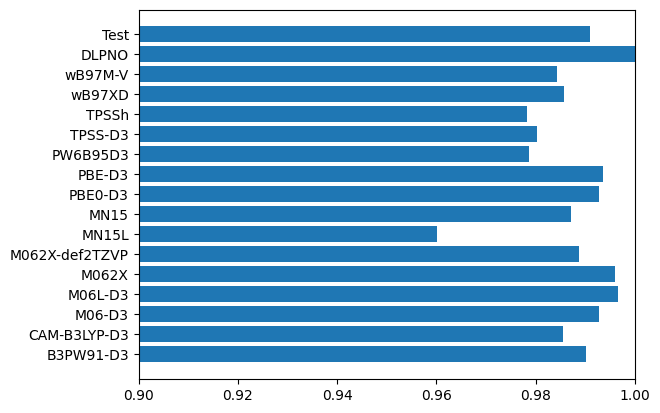

In [26]:
from sklearn.linear_model import LinearRegression
from matplotlib import pyplot as plt
# import numpy as np
standard_value = np.array(all_results['DLPNO'])[[0,1,2,3,4,5,6,6,7,13]]
scores = []
for key in all_column:
    easy_value = np.array(all_results[key])[[0,1,2,3,4,5,6,6,7,13]]
    X = np.array(easy_value).reshape(-1, 1)
    y = np.array(standard_value).reshape(-1, 1)
    model = LinearRegression().fit(X, y)
    scores.append(model.score(X, y))
    print(f"{key}:{model.score(X, y), model.coef_, model.intercept_}")
plt.barh(all_column, scores)
plt.xlim(0.9, 1)
plt.show()


In [16]:
np.array([name for idx, name in enumerate(all_column) if scores[idx] < scores[-1]])

array(['CAM-B3LYP-D3', 'M06-D3', 'MN15L', 'MN15', 'PW6B95D3', 'TPSS-D3',
       'TPSSh', 'wB97XD', 'wB97M-V'], dtype='<U12')

In [23]:
np.array([name for idx, name in enumerate(all_column) if scores[idx] < scores[-1]])

array(['B3PW91-D3', 'CAM-B3LYP-D3', 'M062X-def2TZVP', 'MN15L', 'MN15',
       'PW6B95D3', 'TPSS-D3', 'TPSSh', 'wB97XD', 'wB97M-V'], dtype='<U14')

In [52]:
# Time Cost
all_times = {}
pattern = r'TOTAL RUN TIME:\s*(?P<days>\d+)\s*days\s*(?P<hours>\d+)\s*hours\s*(?P<minutes>\d+)\s*minutes\s*(?P<seconds>\d+)\s*seconds\s*(?P<msec>\d+)\s*msec'
time_to_min = lambda x: int(x[0])*24*60 + int(x[1])*60 + int(x[2]) + int(x[3])/60
for name in calc_dict.keys():
    log = Logfile(rf'E:\work\B_Cl_Nu\Benchmark_new\OPT\{name}.log')
    G_cor[name] = log.all_engs[-1]
    for method in dft_methods.keys():
        log_file = rf'E:\work\B_Cl_Nu\Benchmark_new\SPE\{method}_{name}.log'
        if "M05" in method:
            continue
        temp_log = Logfile(log_file)
        if method not in all_times.keys():
            all_times[method] = temp_log.running_time
        else:
            all_times[method] += temp_log.running_time
    for method in ['wB97M-V', "DLPNO"]:
        with open(rf'E:\work\B_Cl_Nu\Benchmark_new\{method}\{method}_{name}.out', "rt") as f:
            for line in f.readlines():
                if "TOTAL RUN TIME" in line:
                    time_line = line
                    break
        match = re.search(pattern, time_line)
        time = time_to_min(match.groups())
        if method not in all_times.keys():
            all_times[method] = time
        else:
            all_times[method] += time


In [55]:
all_times['Test'] = all_times['wB97XD']

In [56]:
len(all_times)

17

C:\Users\Jackie\AppData\Local\Temp\ipykernel_111384\2261407442.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  score_df['name'].iloc[-1] = "wB97XD"


(0.95, 1.0)

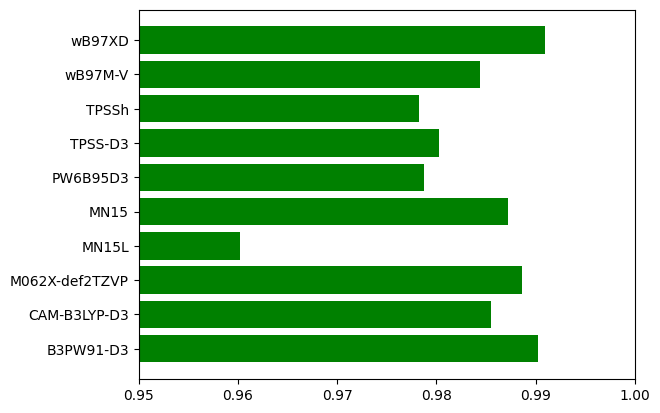

In [125]:
score_df = pd.DataFrame({"name": all_column, "socres": scores, 'times': all_times.values()})
score_df = score_df.loc[(score_df['socres'] <= score_df['socres'].iloc[-1]) ]#| (score_df['name'] == 'DLPNO')]
score_df = score_df.loc[score_df['name'] != 'wB97XD']
score_df['name'].iloc[-1] = "wB97XD"
plt.barh(score_df['name'], score_df['socres'], color='green')
plt.xlim(0.95, 1)


<BarContainer object of 11 artists>

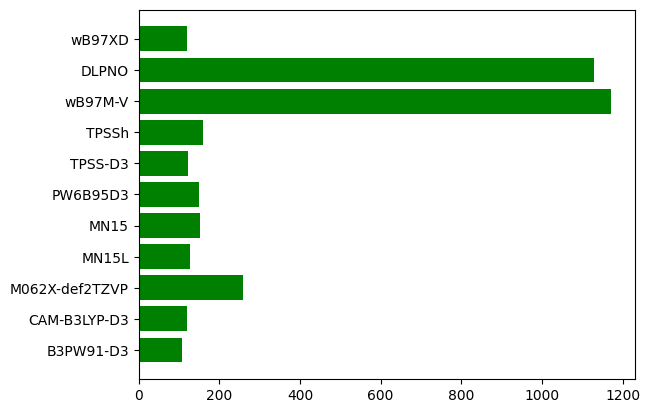

In [80]:
plt.barh(score_df['name'], score_df['times'], color='green')
# plt.xlim(0, 700)

In [83]:
for key in calc_dict.keys():
    print(key, combined_data[key][0])

B_00388_L_00001_r [B-:1]([H:3])([H:4])[N+:6]([C:5]([H:9])([H:10])[H:11])([C:7]([H:12])([H:13])[H:14])[C:8]([H:15])([H:16])[H:17]
Cl_00475_r C(=[C:1]([C:2]([H:6])([H:7])[H:8])[Cl:3])([H:4])[H:5]
B_00388_L_00001_Cl_00475 O=[C:1]([O:2][C:3]([Cl:4])[Cl:5])[O:6][C:7]([Cl:8])([Cl:9])[Cl:10]
Cl_00477_r Cl[c:1]1[c:2]([H:8])[c:3]([H:9])[c:4]([Cl:5])[c:6]([H:10])[c:7]1[H:11]
B_00388_L_00001_Cl_00477 O=[C:1]([O:2][C:3]([Cl:4])[Cl:5])[O:6][C:7]([Cl:8])([Cl:9])[Cl:10]
Cl_00490_r C(=[C:1]([F:2])[Cl:3])([H:4])[H:5]
B_00388_L_00001_Cl_00490 O=[C:1]([O:2][C:3]([Cl:4])[Cl:5])[O:6][C:7]([Cl:8])([Cl:9])[Cl:10]
Cl_00506_r C([C:1]([C:2]([H:8])([H:9])[H:10])([C:3]([H:11])([H:12])[H:13])[Cl:4])([H:5])([H:6])[H:7]
B_00388_L_00001_Cl_00506 O=[C:1]([O:2][C:3]([Cl:4])[Cl:5])[O:6][C:7]([Cl:8])([Cl:9])[Cl:10]
Cl_00519_r Cl[C:1]1([H:7])[C:2]([H:8])([H:9])[C:3]([H:10])([H:11])[O:4][C:5]([H:12])([H:13])[C:6]1([H:14])[H:15]
B_00388_L_00001_Cl_00519 O=[C:1]([O:2][C:3]([Cl:4])[Cl:5])[O:6][C:7]([Cl:8])([Cl:9])[Cl:10]
B_00

In [123]:
len(np.unique(reaction_df['Cl_Index']))

178